<a href="https://colab.research.google.com/github/gamzedrn/ai-student-eda/blob/main/ai_assistant_usage_student_life.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kütüphanelerin Yüklenmesi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version:  {np.__version__}')
print(f'Seaborn version:{sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version:  2.0.2
Seaborn version:0.13.2


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")

print("Path to dataset files:", path)

100%|██████████| 14.9k/14.9k [00:00<00:00, 7.85MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/abcsds/pokemon/versions/2


**bold text**## Verinin (Verilerin) Yüklenmesi

In [3]:
df = pd.read_csv(path + '/Pokemon.csv')

print('\nPokemon Dataset')
print('=' * 50)
print(f'Boyut      : {df.shape[0]} satır, {df.shape[1]} sütun')
print(f'Bellek     : {df.memory_usage(deep=True).sum() / 1024:.2f} KB')
print('=' * 50)


Pokemon Dataset
Boyut      : 800 satır, 13 sütun
Bellek     : 178.96 KB


In [4]:
print('\nİlk 5 Satır:')
df.head()



İlk 5 Satır:


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [5]:
print('\nson beş satır:')
df.tail()


son beş satır:


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True
799,721,Volcanion,Fire,Water,600,80,110,120,130,90,70,6,True


In [6]:
#rastgele beş satır
df.sample(5)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
523,472,Gliscor,Ground,Flying,510,75,95,125,45,75,95,4,False
449,404,Luxio,Electric,NaN,363,60,85,49,60,49,60,4,False
394,360,Wynaut,Psychic,NaN,260,95,23,48,23,48,23,3,False
582,523,Zebstrika,Electric,NaN,497,75,100,63,80,63,116,5,False
356,325,Spoink,Psychic,NaN,330,60,25,35,70,80,60,3,False


## VERİ TİPLERİ VE TEMEL BİLGİLER

In [7]:
print('\n--- Veri Tipleri ve Eksik Değer Özeti ---')
dtype_df = pd.DataFrame({
    'Sütun'       : df.columns,
    'Veri Tipi'   : df.dtypes.values,
    'Null Sayısı' : df.isnull().sum().values,
    'Null Oranı %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Unique'      : df.nunique().values
})
print(dtype_df.to_string(index=False))

df.info()

# Sayısal değişkenlerin temel istatistikleri
print('\n--- Sayısal Değişkenler ---')
display(df.describe().T)

# Kategorik değişkenlerin temel istatistikleri
print('\n--- Kategorik Değişkenler ---')
display(df.describe(include=['object', 'category']).T)


--- Veri Tipleri ve Eksik Değer Özeti ---
     Sütun Veri Tipi  Null Sayısı  Null Oranı %  Unique
         #     int64            0          0.00     721
      Name    object            0          0.00     800
    Type 1    object            0          0.00      18
    Type 2    object          386         48.25      18
     Total     int64            0          0.00     200
        HP     int64            0          0.00      94
    Attack     int64            0          0.00     111
   Defense     int64            0          0.00     103
   Sp. Atk     int64            0          0.00     105
   Sp. Def     int64            0          0.00      92
     Speed     int64            0          0.00     108
Generation     int64            0          0.00       6
 Legendary      bool            0          0.00       2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      -----------

,count,mean,std,min,25%,50%,75%,max
#,800.00,362.81,208.34,1.00,184.75,364.50,539.25,721.00
Total,800.00,435.10,119.96,180.00,330.00,450.00,515.00,780.00
HP,800.00,69.26,25.53,1.00,50.00,65.00,80.00,255.00
Attack,800.00,79.00,32.46,5.00,55.00,75.00,100.00,190.00
Defense,800.00,73.84,31.18,5.00,50.00,70.00,90.00,230.00
Sp. Atk,800.00,72.82,32.72,10.00,49.75,65.00,95.00,194.00
Sp. Def,800.00,71.90,27.83,20.00,50.00,70.00,90.00,230.00
Speed,800.00,68.28,29.06,5.00,45.00,65.00,90.00,180.00
Generation,800.00,3.32,1.66,1.00,2.00,3.00,5.00,6.00



--- Kategorik Değişkenler ---


,count,unique,top,freq
Name,800,800,PumpkabooSuper Size,1
Type 1,800,18,Water,112
Type 2,414,18,Flying,97


## EKSİK VERİ ANALİZİ


--- Eksik Veri Tablosu ---
            eksik_sayı  eksik_oran_%
Type 2             386         48.25
#                    0          0.00
Name                 0          0.00
Type 1               0          0.00
Total                0          0.00
HP                   0          0.00
Attack               0          0.00
Defense              0          0.00
Sp. Atk              0          0.00
Sp. Def              0          0.00
Speed                0          0.00
Generation           0          0.00
Legendary            0          0.00


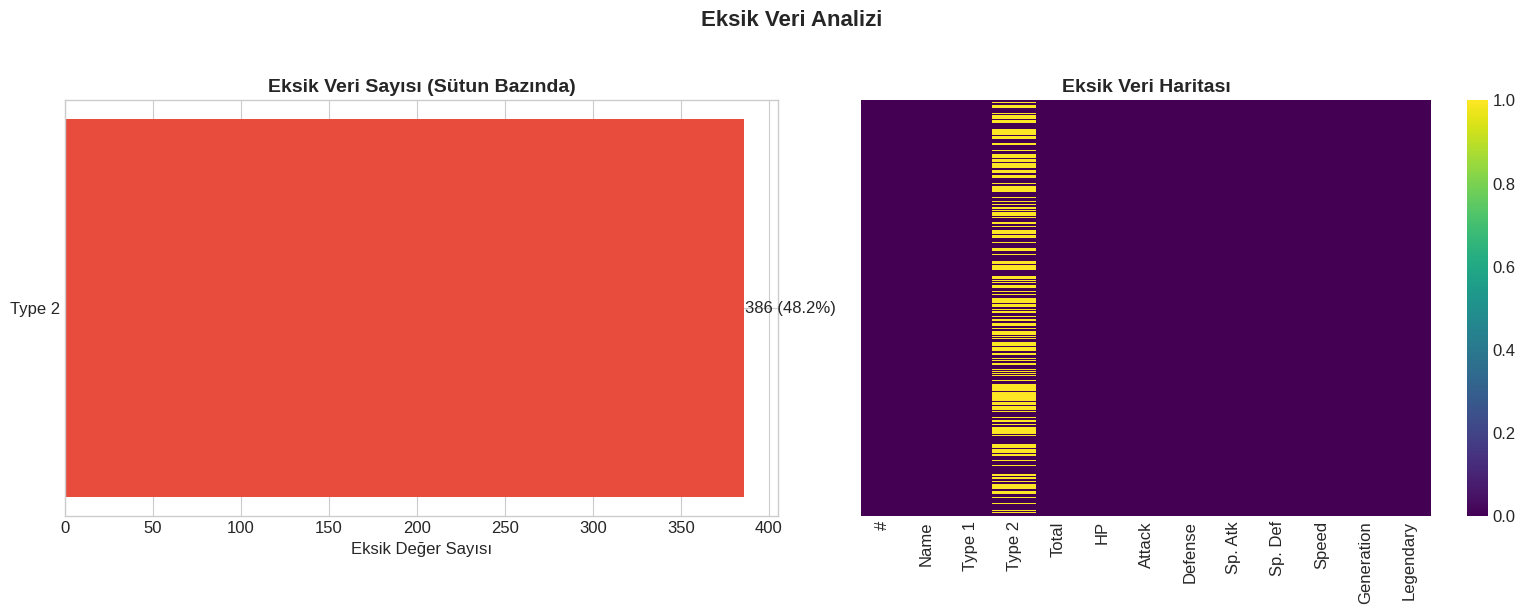

In [10]:
eksik       = df.isnull().sum()
eksik_oran  = (eksik / len(df) * 100).round(2)
eksik_df    = pd.concat([eksik, eksik_oran], axis=1)
eksik_df.columns = ['eksik_sayı', 'eksik_oran_%']
print('\n--- Eksik Veri Tablosu ---')
print(eksik_df.sort_values('eksik_oran_%', ascending=False))

# Eksik veri görselleştirmesi
eksik_olan = df.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

if len(eksik_olan) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
              for x in (eksik_olan / len(df) * 100)]

    axes[0].barh(eksik_olan.index, eksik_olan.values, color=colors)
    axes[0].set_title('Eksik Veri Sayısı (Sütun Bazında)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Eksik Değer Sayısı')
    for i, val in enumerate(eksik_olan.values):
        axes[0].text(val + 0.3, i, f'{val} ({val/len(df)*100:.1f}%)', va='center')

    sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[1])
    axes[1].set_title('Eksik Veri Haritası', fontsize=14, fontweight='bold')

    plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Eksik veri bulunmuyor!')

EKSİK VERİ STRATEJİLERİ

In [11]:
df_clean = df.copy()

In [9]:
### Bu alanı çalıştırma. Çoğu veri setinde çalıştırılması için uygun bir genel şablon. Ama pokemon veri setine uygun değil.


# Sayısal sütunlar → medyan ile doldur
sayisal_sutunlar    = df_clean.select_dtypes(include=['int64', 'float64']).columns
kategorik_sutunlar  = df_clean.select_dtypes(include=['object', 'category']).columns

for kolon in sayisal_sutunlar:
    if df_clean[kolon].isnull().sum() > 0:
        medyan = df_clean[kolon].median()
        df_clean[kolon].fillna(medyan, inplace=True)
        print(f'{kolon} → medyan ({medyan:.2f}) ile dolduruldu')

# Kategorik sütunlar → mod ile doldur
for kolon in kategorik_sutunlar:
    if df_clean[kolon].isnull().sum() > 0:
        mod = df_clean[kolon].mode()[0]
        df_clean[kolon].fillna(mod, inplace=True)
        print(f'{kolon} → mod ({mod}) ile dolduruldu')

print('\nTemizleme sonrası eksik değerler:')
print(df_clean.isnull().sum())

Type 2 → mod (Flying) ile dolduruldu

Temizleme sonrası eksik değerler:
#             0
Name          0
Type 1        0
Type 2        0
Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


In [12]:
# without type columns
df_final = df_clean.drop(columns=['Type 2'])

print("'Type 2' sütunu başarıyla kaldırıldı.")
print(f"Yeni veri seti boyutu: {df_final.shape}")
print("\nKalan Sütunlar:")
print(df_final.columns.tolist())

# İlk 5 satırı kontrol edelim
display(df_final.head())

'Type 2' sütunu başarıyla kaldırıldı.
Yeni veri seti boyutu: (800, 12)

Kalan Sütunlar:
['#', 'Name', 'Type 1', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']


,#,Name,Type 1,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,309,39,52,43,60,50,65,1,False


## TEK DEĞİŞKENLİ ANALİZ — SAYISAL DEĞİŞKENLER

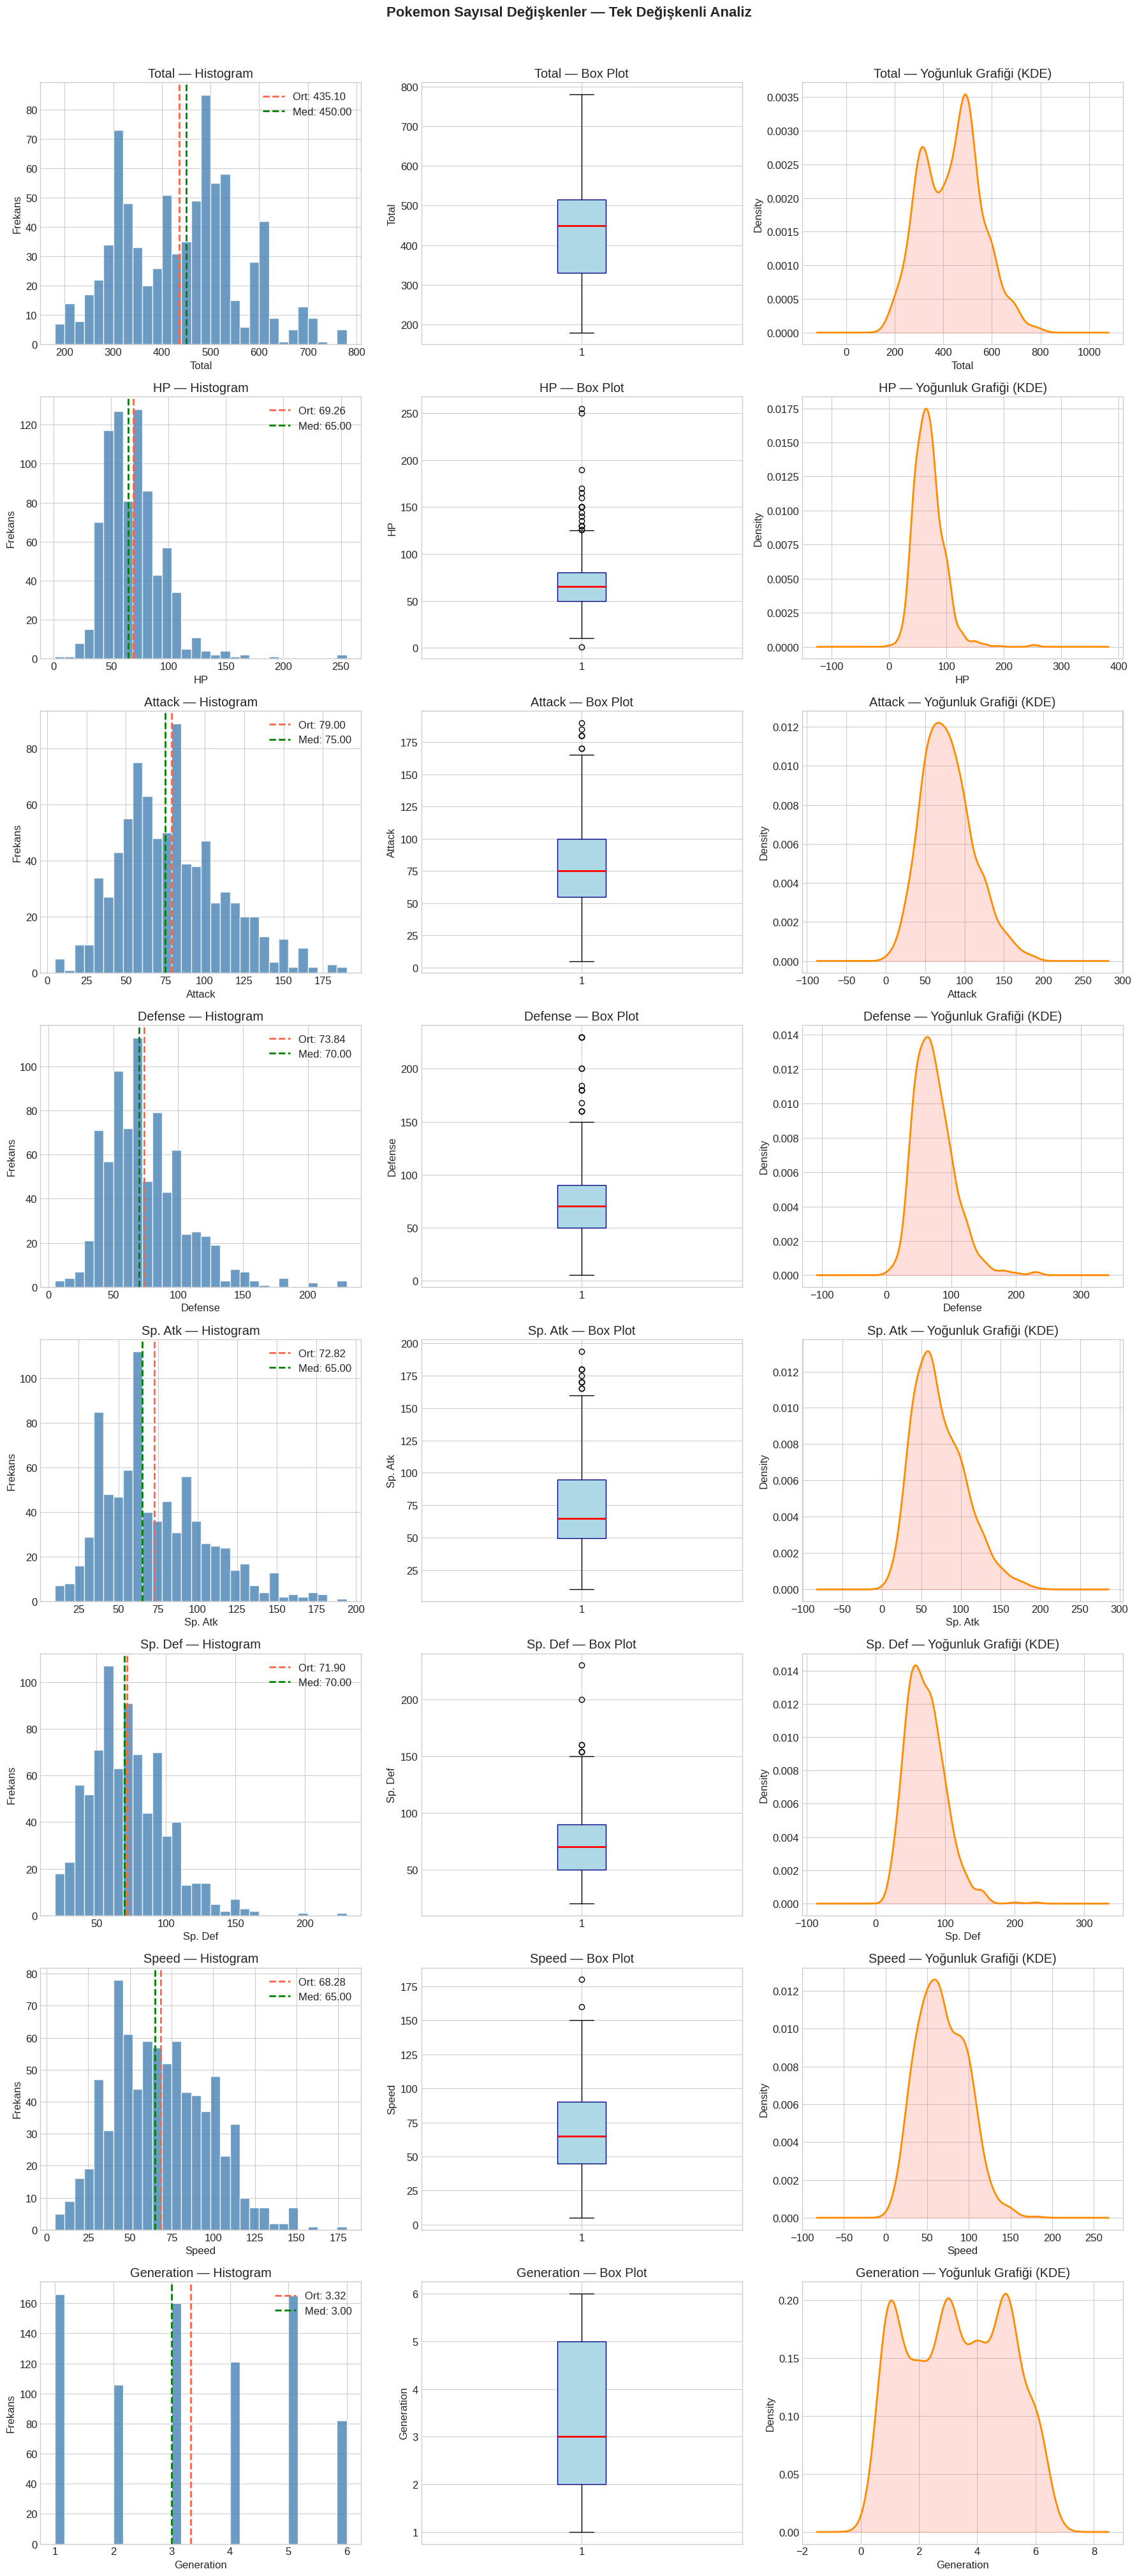


Sayısal Değişkenler — Detaylı İstatistikler

TOTAL
  Ortalama    : 435.10
  Medyan      : 450.00
  Std Sapma   : 119.96
  Min / Maks  : 180.00 / 780.00
  Çarpıklık   : 0.15
  Basıklık    : -0.51
  IQR         : 185.00

HP
  Ortalama    : 69.26
  Medyan      : 65.00
  Std Sapma   : 25.53
  Min / Maks  : 1.00 / 255.00
  Çarpıklık   : 1.57
  Basıklık    : 7.23
  IQR         : 30.00

ATTACK
  Ortalama    : 79.00
  Medyan      : 75.00
  Std Sapma   : 32.46
  Min / Maks  : 5.00 / 190.00
  Çarpıklık   : 0.55
  Basıklık    : 0.17
  IQR         : 45.00

DEFENSE
  Ortalama    : 73.84
  Medyan      : 70.00
  Std Sapma   : 31.18
  Min / Maks  : 5.00 / 230.00
  Çarpıklık   : 1.16
  Basıklık    : 2.73
  IQR         : 40.00

SP. ATK
  Ortalama    : 72.82
  Medyan      : 65.00
  Std Sapma   : 32.72
  Min / Maks  : 10.00 / 194.00
  Çarpıklık   : 0.74
  Basıklık    : 0.30
  IQR         : 45.25

SP. DEF
  Ortalama    : 71.90
  Medyan      : 70.00
  Std Sapma   : 27.83
  Min / Maks  : 20.00 / 230.00
  Ça

In [14]:
import matplotlib.pyplot as plt

# Pokemon veri setine uygun sayısal kolonlar
sayisal_kolonlar = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation']

fig, axes = plt.subplots(len(sayisal_kolonlar), 3, figsize=(18, 5 * len(sayisal_kolonlar)))

for i, kolon in enumerate(sayisal_kolonlar):
    # df_final üzerinden veriyi alıyoruz
    veri = df_final[kolon].dropna()

    # Histogram
    axes[i, 0].hist(veri, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i, 0].axvline(veri.mean(),   color='tomato', linestyle='dashed', linewidth=2,
                       label=f'Ort: {veri.mean():.2f}')
    axes[i, 0].axvline(veri.median(), color='green',  linestyle='dashed', linewidth=2,
                       label=f'Med: {veri.median():.2f}')
    axes[i, 0].set_title(f'{kolon} — Histogram')
    axes[i, 0].legend()
    axes[i, 0].set_xlabel(kolon)
    axes[i, 0].set_ylabel('Frekans')

    # Box Plot
    axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{kolon} — Box Plot')
    axes[i, 1].set_ylabel(kolon)

    # KDE
    veri.plot.kde(ax=axes[i, 2], color='darkorange', linewidth=2)
    axes[i, 2].fill_between(axes[i, 2].lines[0].get_xdata(),
                            axes[i, 2].lines[0].get_ydata(),
                            color='tomato', alpha=0.2)
    axes[i, 2].set_title(f'{kolon} — Yoğunluk Grafiği (KDE)')
    axes[i, 2].set_xlabel(kolon)

plt.suptitle('Pokemon Sayısal Değişkenler — Tek Değişkenli Analiz',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# İstatistiksel özet
print('\nSayısal Değişkenler — Detaylı İstatistikler')
print('=' * 70)
for kolon in sayisal_kolonlar:
    veri = df_final[kolon].dropna()
    print(f'\n{kolon.upper()}')
    print(f'  Ortalama    : {veri.mean():.2f}')
    print(f'  Medyan      : {veri.median():.2f}')
    print(f'  Std Sapma   : {veri.std():.2f}')
    print(f'  Min / Maks  : {veri.min():.2f} / {veri.max():.2f}')
    print(f'  Çarpıklık   : {veri.skew():.2f}')
    print(f'  Basıklık    : {veri.kurtosis():.2f}')
    print(f'  IQR         : {veri.quantile(0.75) - veri.quantile(0.25):.2f}')
    print('=' * 70)

## TEK DEĞİŞKENLİ ANALİZ — KATEGORİK DEĞİŞKENLER

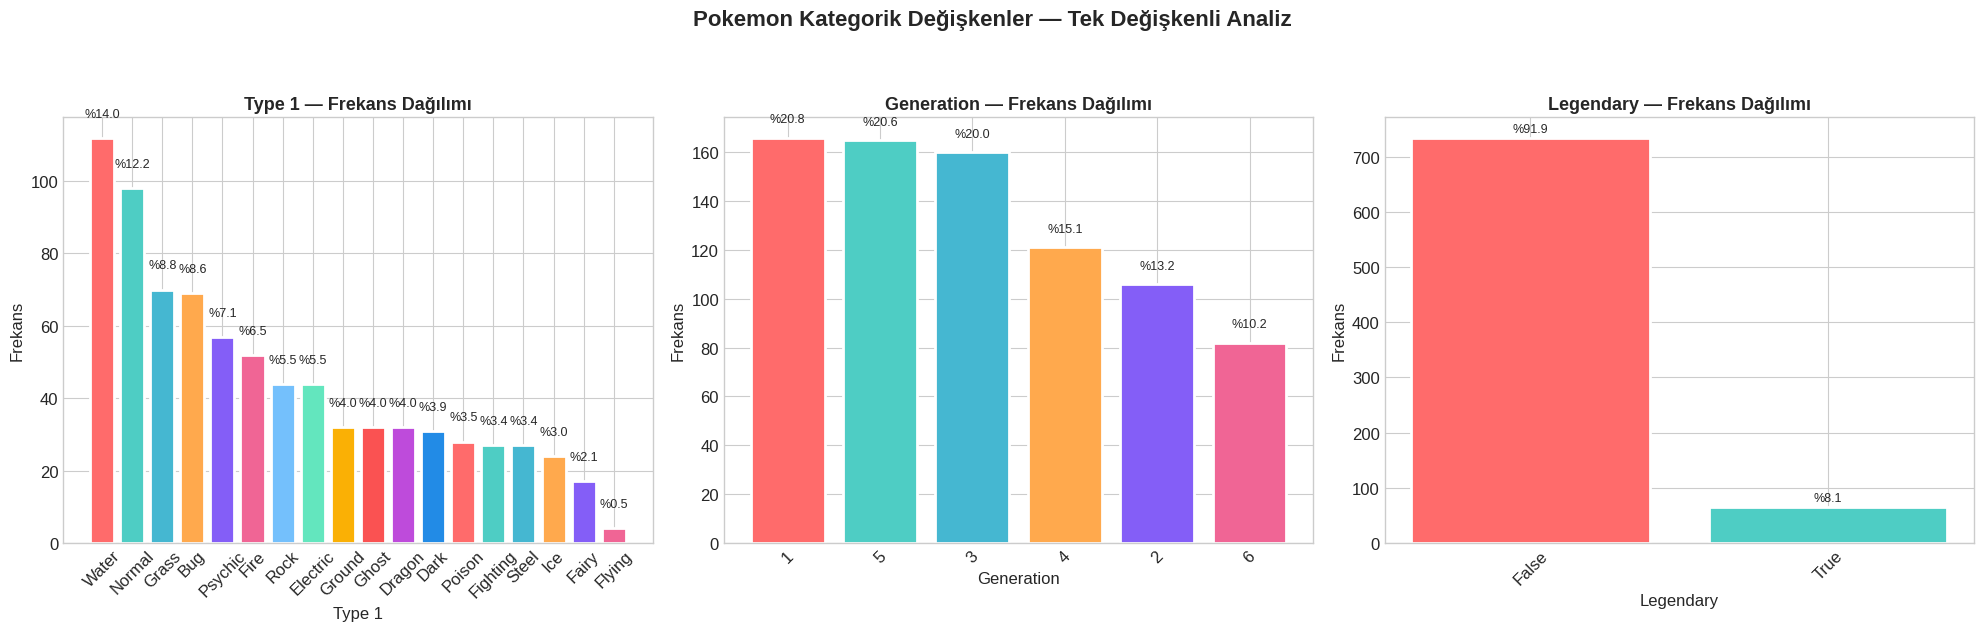

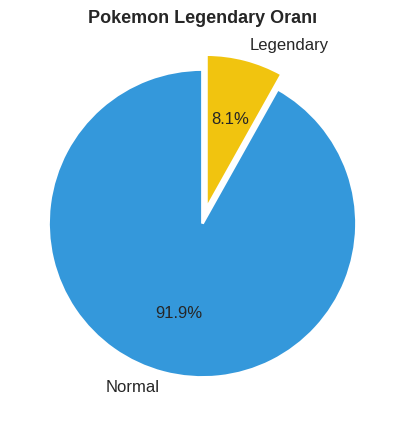

In [15]:
kategorik_kolonlar = ['Type 1', 'Generation', 'Legendary']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.flatten()

renkler = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA94D', '#845EF7', '#F06595',
           '#74C0FC', '#63E6BE', '#FAB005', '#FA5252', '#BE4BDB', '#228BE6']

for i, kolon in enumerate(kategorik_kolonlar):
    degerler = df_final[kolon].value_counts()
    yuzde    = (degerler / len(df_final) * 100).round(1)

    bars = axes[i].bar(degerler.index.astype(str), degerler.values,
                       color=renkler[:len(degerler)], edgecolor='white', linewidth=2)
    axes[i].set_title(f'{kolon} — Frekans Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(kolon)
    axes[i].set_ylabel('Frekans')
    axes[i].tick_params(axis='x', rotation=45)

    for bar, pct in zip(bars, yuzde.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 5,
                     f'%{pct}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Pokemon Kategorik Değişkenler — Tek Değişkenli Analiz',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Legendary Durumu için Pasta Grafiği
fig, ax = plt.subplots(figsize=(6, 5))
legendary_counts = df_final['Legendary'].value_counts()
ax.pie(legendary_counts.values,
       labels=['Normal', 'Legendary'],
       autopct='%1.1f%%',
       colors=['#3498db', '#f1c40f'],
       startangle=90,
       explode=(0, 0.1),
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Pokemon Legendary Oranı', fontsize=13, fontweight='bold')
plt.show()

## ÇİFT DEĞİŞKENLİ ANALİZ

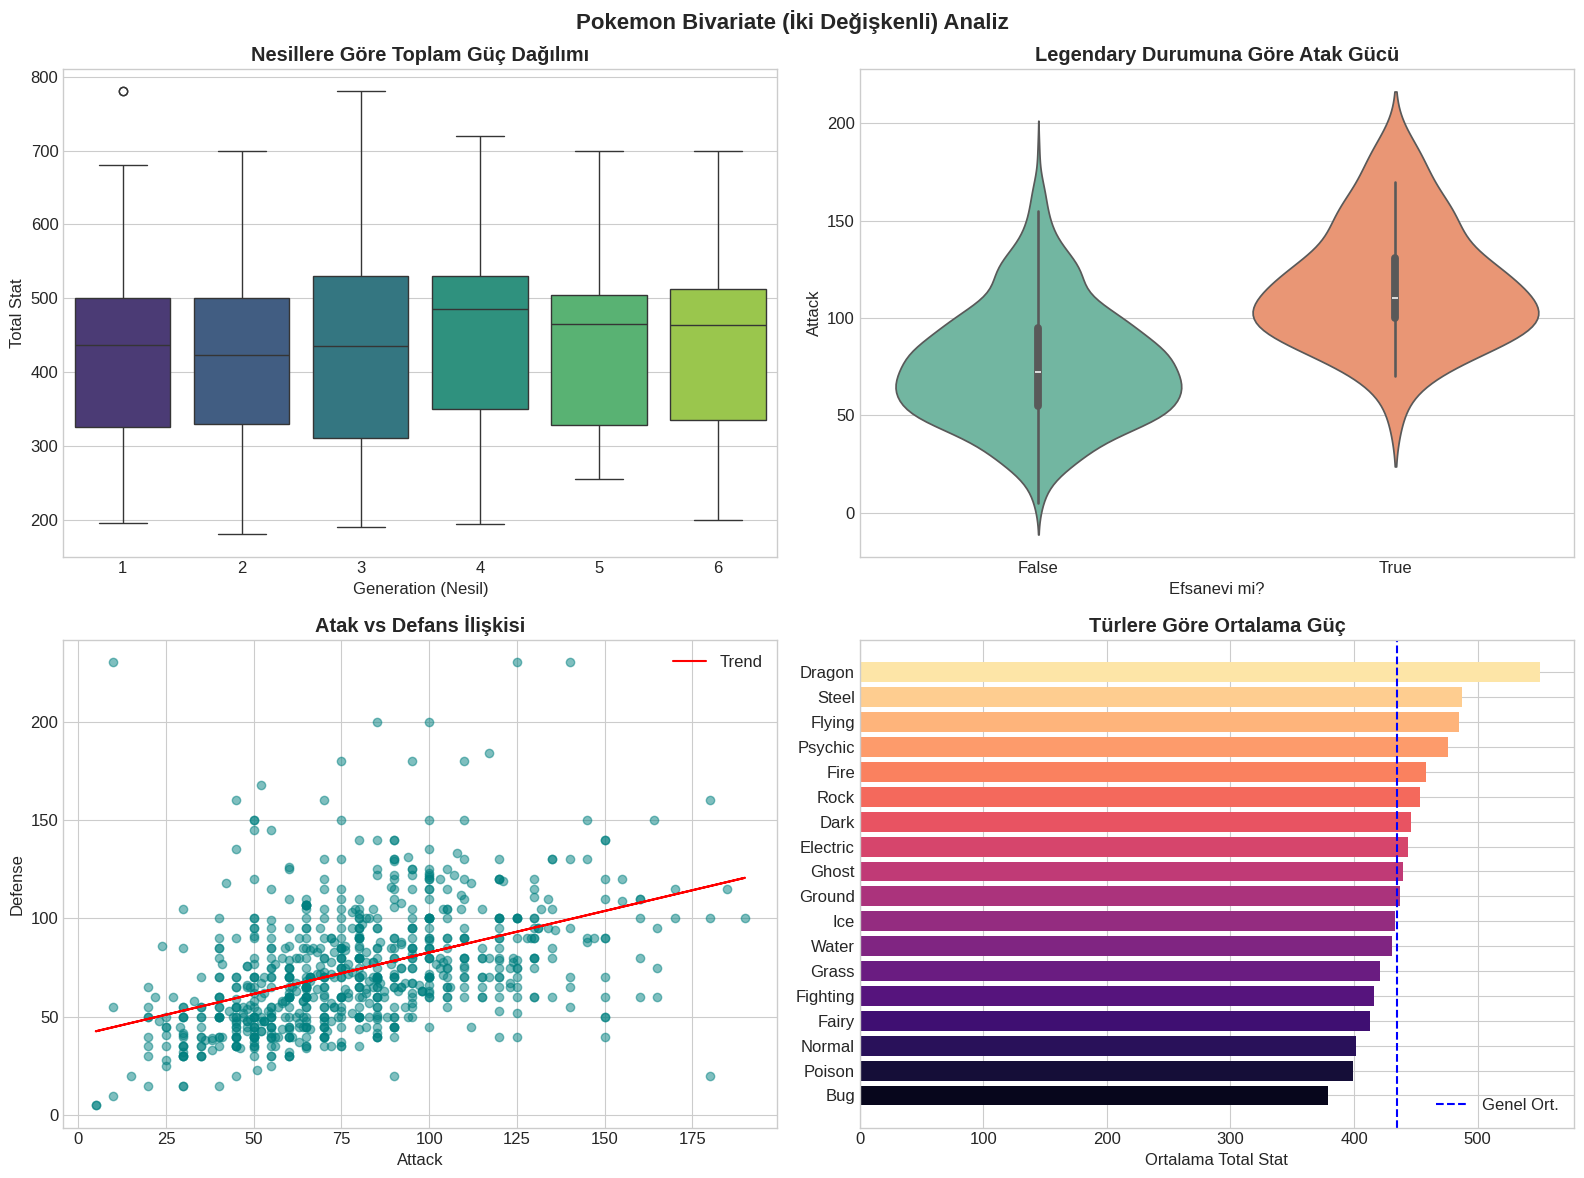

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Generation -> Total Stat (Boxplot)
sns.boxplot(data=df_final, x='Generation', y='Total', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Nesillere Göre Toplam Güç Dağılımı', fontweight='bold')
axes[0, 0].set_xlabel('Generation (Nesil)')
axes[0, 0].set_ylabel('Total Stat')

# 2) Legendary -> Attack (Violin Plot)
sns.violinplot(data=df_final, x='Legendary', y='Attack', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Legendary Durumuna Göre Atak Gücü', fontweight='bold')
axes[0, 1].set_xlabel('Efsanevi mi?')
axes[0, 1].set_ylabel('Attack')

# 3) Attack vs Defense (Scatter + Trend Line)
axes[1, 0].scatter(df_final['Attack'], df_final['Defense'], alpha=0.5, color='teal')
z = np.polyfit(df_final['Attack'], df_final['Defense'], 1)
p = np.poly1d(z)
axes[1, 0].plot(df_final['Attack'], p(df_final['Attack']), color='red', label='Trend')
axes[1, 0].set_title('Atak vs Defans İlişkisi', fontweight='bold')
axes[1, 0].set_xlabel('Attack')
axes[1, 0].set_ylabel('Defense')
axes[1, 0].legend()

# 4) Type 1 -> Mean Total Stat (Horizontal Bar)
type_mean = df_final.groupby('Type 1')['Total'].mean().sort_values()
axes[1, 1].barh(type_mean.index, type_mean.values, color=sns.color_palette('magma', len(type_mean)))
axes[1, 1].axvline(df_final['Total'].mean(), color='blue', linestyle='--', label='Genel Ort.')
axes[1, 1].set_title('Türlere Göre Ortalama Güç', fontweight='bold')
axes[1, 1].set_xlabel('Ortalama Total Stat')
axes[1, 1].legend()

plt.suptitle('Pokemon Bivariate (İki Değişkenli) Analiz', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## KATEGORİK vs KATEGORİK

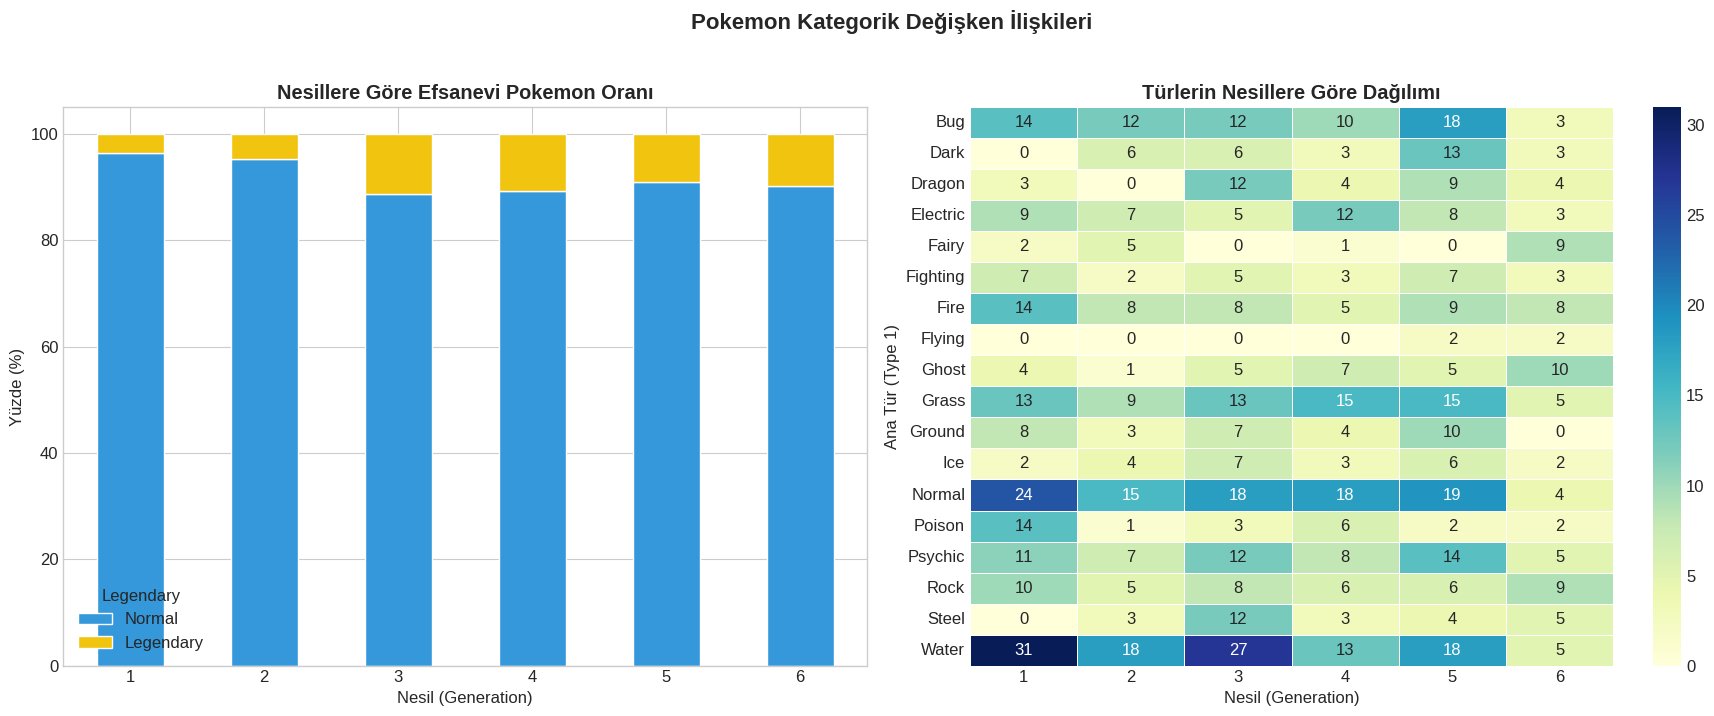

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1) Generation × Legendary (Yüzdelik Yığın Grafik)
ct_legendary = pd.crosstab(df_final['Generation'], df_final['Legendary'], normalize='index') * 100
ct_legendary.plot(kind='bar', stacked=True, ax=axes[0], color=['#3498db', '#f1c40f'], edgecolor='white')
axes[0].set_title('Nesillere Göre Efsanevi Pokemon Oranı', fontweight='bold')
axes[0].set_xlabel('Nesil (Generation)')
axes[0].set_ylabel('Yüzde (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Legendary', labels=['Normal', 'Legendary'])

# 2) Generation × Type 1 (Heatmap)
ct_type = pd.crosstab(df_final['Type 1'], df_final['Generation'])
sns.heatmap(ct_type, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5, ax=axes[1])
axes[1].set_title('Türlerin Nesillere Göre Dağılımı', fontweight='bold')
axes[1].set_xlabel('Nesil (Generation)')
axes[1].set_ylabel('Ana Tür (Type 1)')

plt.suptitle('Pokemon Kategorik Değişken İlişkileri', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## KORELASYON MATRİSİ

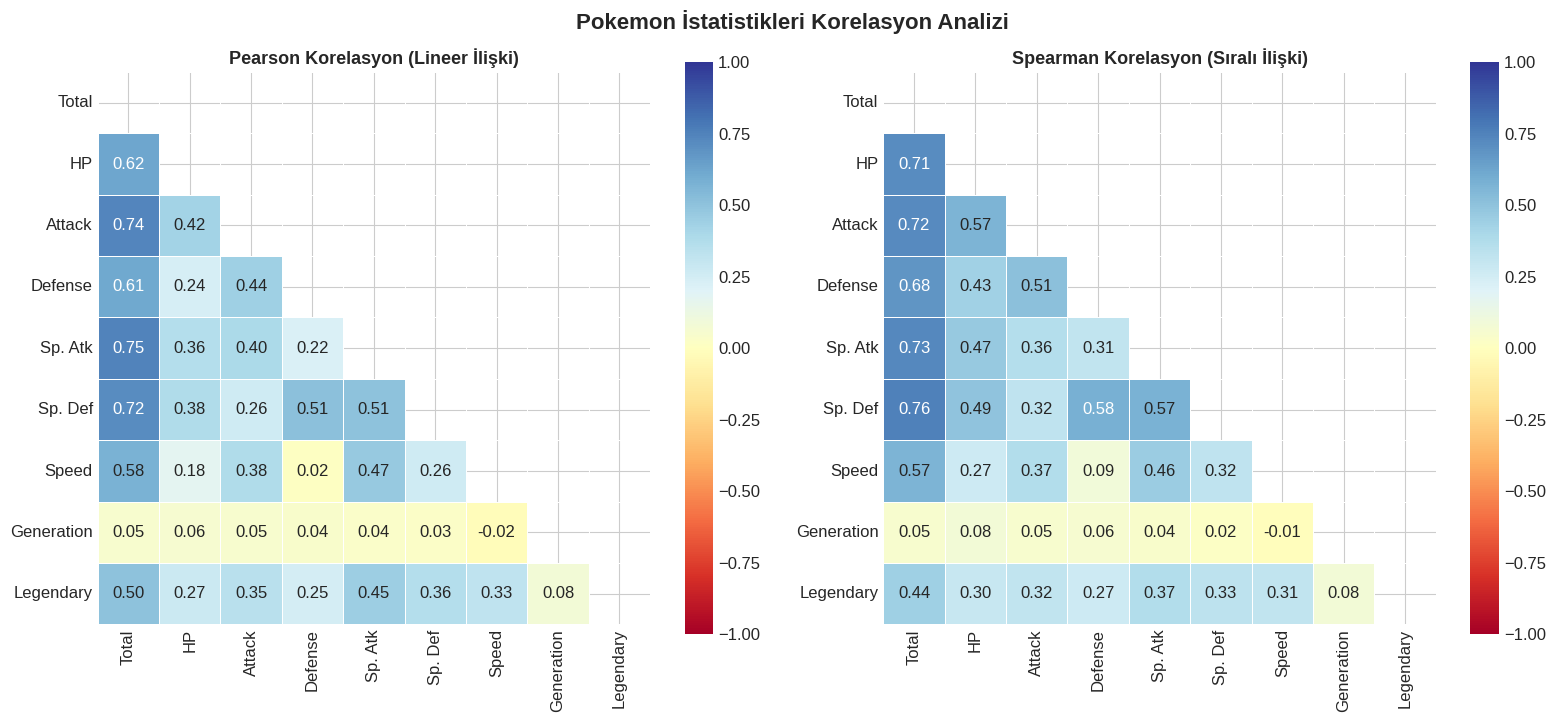


Toplam Güç (Total) ile Korelasyon Sıralaması (Pearson):
Sp. Atk      0.75
Attack       0.74
Sp. Def      0.72
HP           0.62
Defense      0.61
Speed        0.58
Legendary    0.50
Generation   0.05
Name: Total, dtype: float64


In [18]:
# Sayısal kolonları seç ve Legendary sütununu int'e çevir
df_corr = df_final[sayisal_kolonlar].copy()
df_corr['Legendary'] = df_final['Legendary'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))

# Pearson Korelasyon
pearson_corr = df_corr.corr(method='pearson')
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu', center=0, square=True,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson Korelasyon (Lineer İlişki)', fontsize=13, fontweight='bold')

# Spearman Korelasyon
spearman_corr = df_corr.corr(method='spearman')
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu', center=0, square=True,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Spearman Korelasyon (Sıralı İlişki)', fontsize=13, fontweight='bold')

plt.suptitle('Pokemon İstatistikleri Korelasyon Analizi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Toplam Güç (Total) ile en çok korele olan özellikler
print('\nToplam Güç (Total) ile Korelasyon Sıralaması (Pearson):')
print(pearson_corr['Total'].drop(['Total']).sort_values(ascending=False))

## ZAMANSERİSİ ANALİZİ

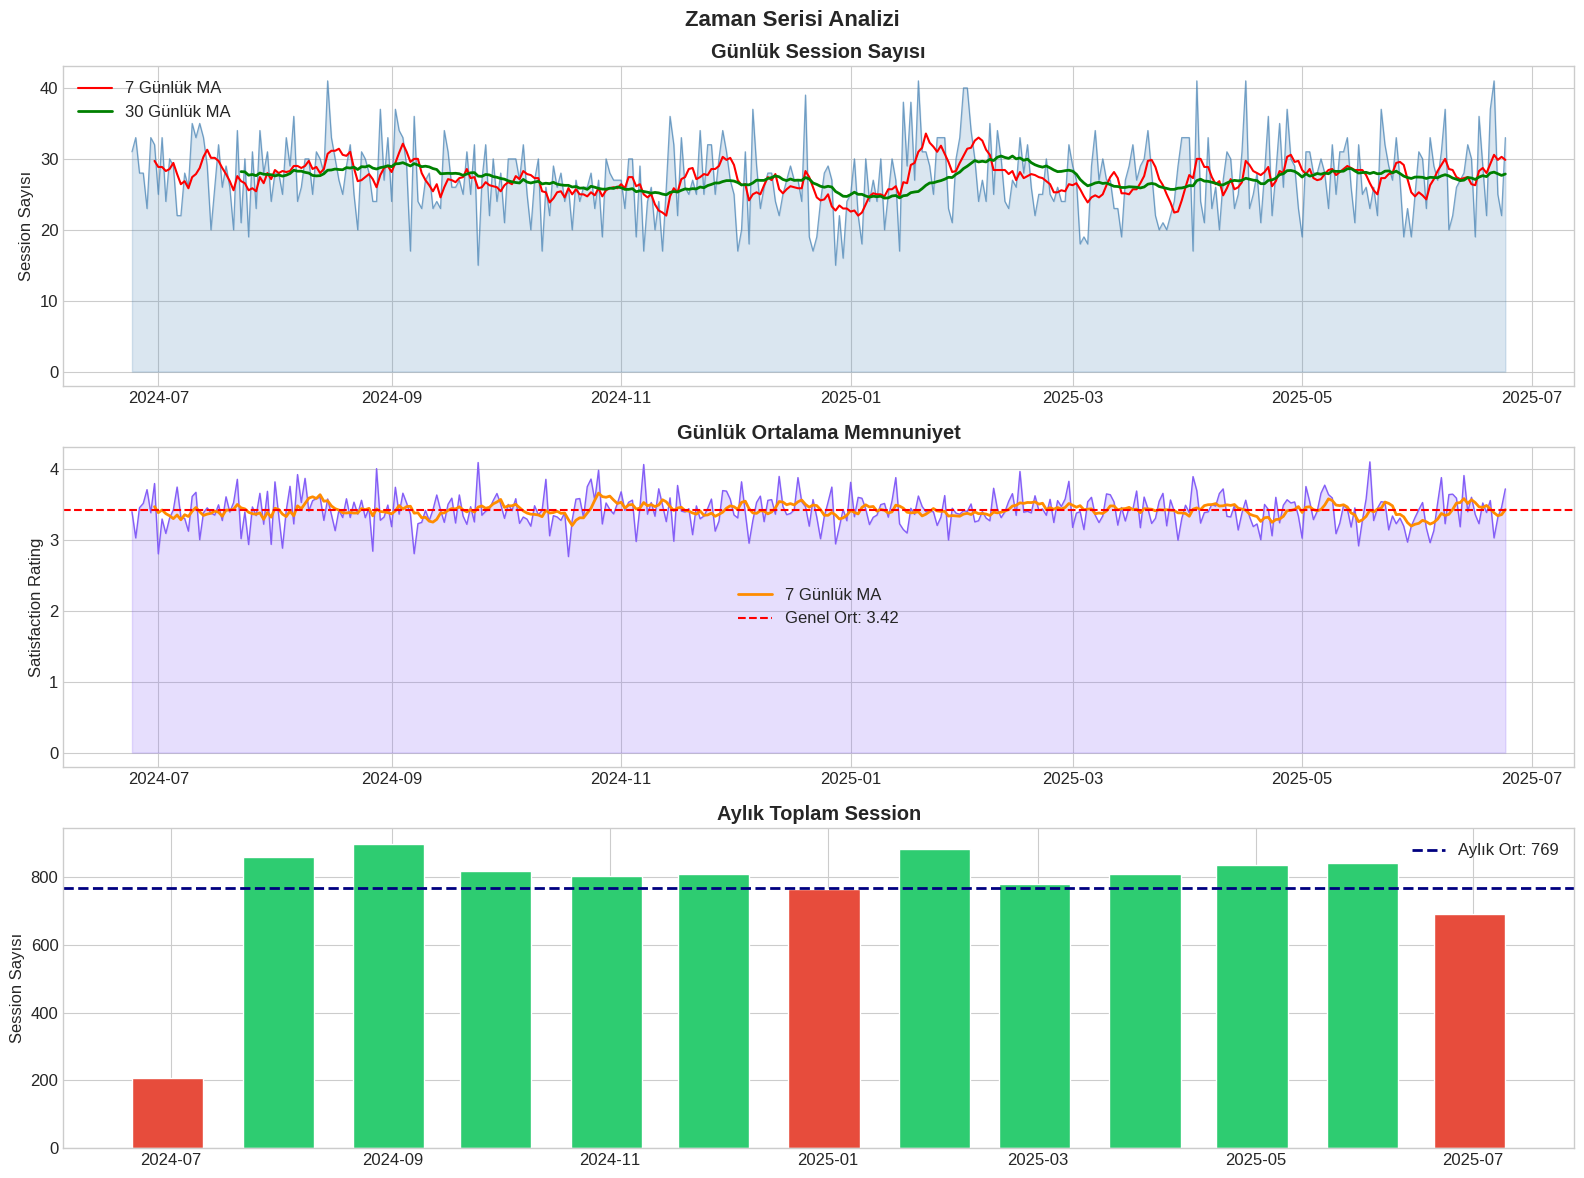

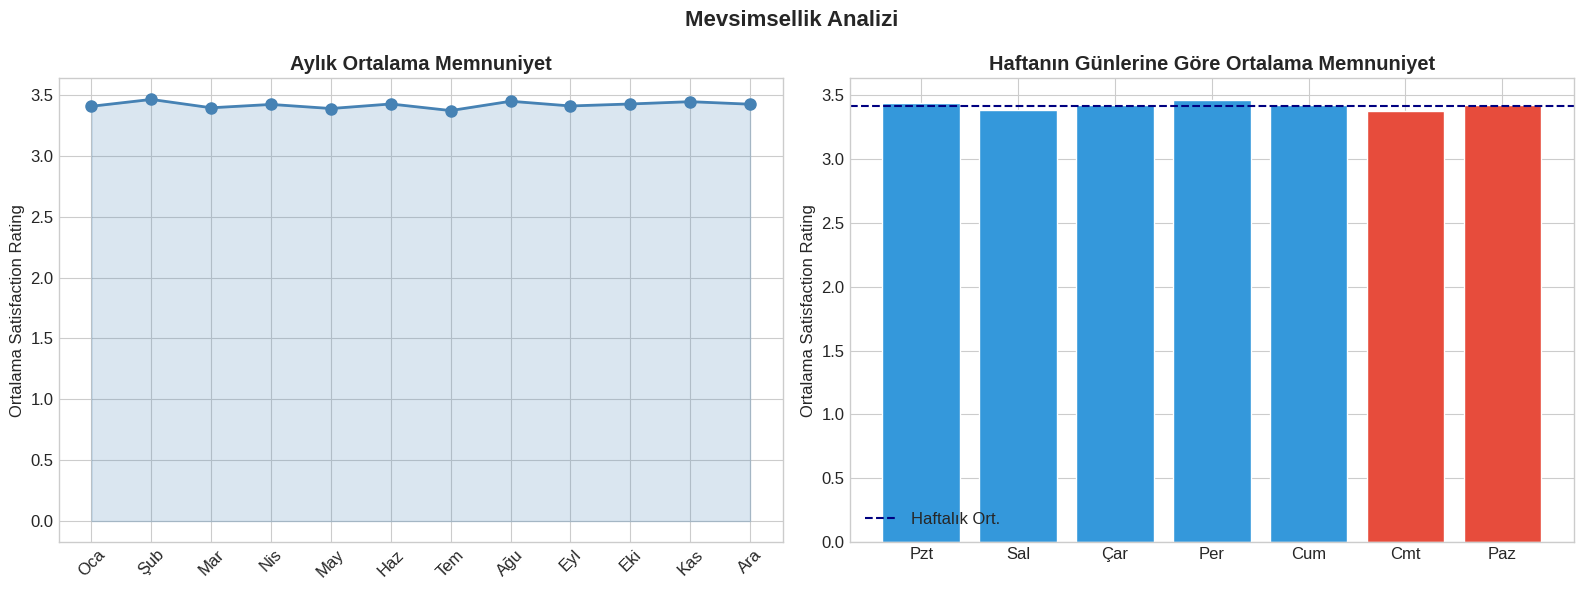

In [ ]:
# Nesillere göre gruplandırma
nesil_ozet = df_final.groupby('Generation').agg(
    pokemon_sayisi=('Name', 'count'),
    ort_guc=('Total', 'mean'),
    ort_hiz=('Speed', 'mean'),
    ort_atak=('Attack', 'mean')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(16, 15))

# 1. Nesillere Göre Pokemon Sayısı
axes[0].bar(nesil_ozet['Generation'], nesil_ozet['pokemon_sayisi'], color='steelblue', alpha=0.7)
axes[0].set_title('Nesillere Göre Toplam Pokemon Sayısı', fontweight='bold')
axes[0].set_ylabel('Sayı')
for i, v in enumerate(nesil_ozet['pokemon_sayisi']):
    axes[0].text(i+1, v + 2, str(v), ha='center')

# 2. Nesillere Göre Ortalama İstatistiklerin Değişimi
axes[1].plot(nesil_ozet['Generation'], nesil_ozet['ort_guc'], 'o-', label='Ort. Güç (Total)', linewidth=2)
axes[1].plot(nesil_ozet['Generation'], nesil_ozet['ort_atak'], 's-', label='Ort. Atak', linewidth=2)
axes[1].plot(nesil_ozet['Generation'], nesil_ozet['ort_hiz'], 'd-', label='Ort. Hız', linewidth=2)
axes[1].set_title('Nesiller Boyunca Ortalama İstatistik Değişimi', fontweight='bold')
axes[1].set_xlabel('Nesil (Generation)')
axes[1].set_ylabel('Puan')
axes[1].legend()

# 3. Nesillere Göre Güç Dağılımı (Violin Plot)
sns.violinplot(data=df_final, x='Generation', y='Total', ax=axes[2], palette='muted')
axes[2].set_title('Nesillere Göre Güç Dağılımı (Total Stat)', fontweight='bold')
axes[2].set_xlabel('Nesil (Generation)')
axes[2].set_ylabel('Total Stat')

plt.suptitle('Pokemon Nesil Bazlı Gelişim Analizi', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

AYKIRLI DEĞER ANALİZİ (IQR)


Aykırı Değer Analizi (IQR Yöntemi)
Total                  IQR=185.00  Alt=52.50  Üst=792.50  Aykırı=0 (0.0%)
HP                     IQR=30.00  Alt=5.00  Üst=125.00  Aykırı=19 (2.4%)
Attack                 IQR=45.00  Alt=-12.50  Üst=167.50  Aykırı=7 (0.9%)
Defense                IQR=40.00  Alt=-10.00  Üst=150.00  Aykırı=13 (1.6%)
Sp. Atk                IQR=45.25  Alt=-18.12  Üst=162.88  Aykırı=10 (1.2%)
Sp. Def                IQR=40.00  Alt=-10.00  Üst=150.00  Aykırı=7 (0.9%)
Speed                  IQR=45.00  Alt=-22.50  Üst=157.50  Aykırı=2 (0.2%)
Generation             IQR=3.00  Alt=-2.50  Üst=9.50  Aykırı=0 (0.0%)


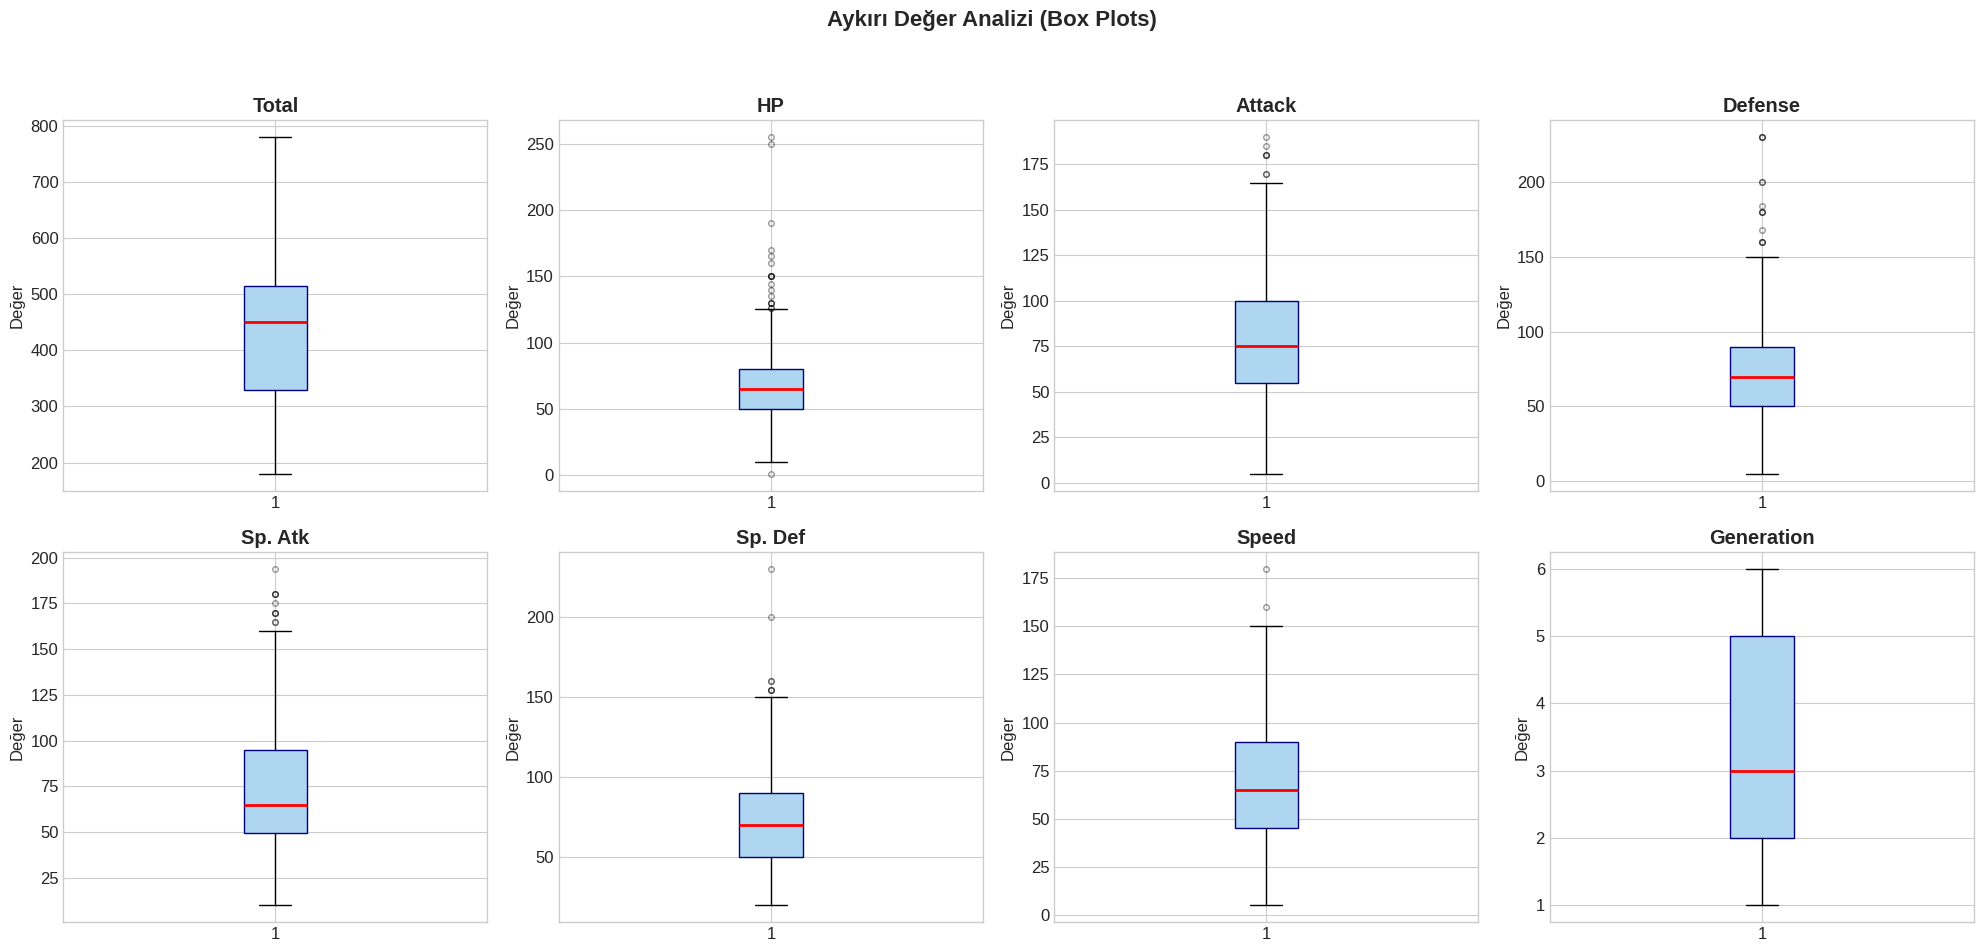

In [20]:
print('\nAykırı Değer Analizi (IQR Yöntemi)')
print('=' * 65)

for kolon in sayisal_kolonlar:
    veri  = df_final[kolon]
    Q1    = veri.quantile(0.25)
    Q3    = veri.quantile(0.75)
    IQR   = Q3 - Q1
    alt   = Q1 - 1.5 * IQR
    ust   = Q3 + 1.5 * IQR
    n_ayk = ((veri < alt) | (veri > ust)).sum()
    print(f'{kolon:<22} IQR={IQR:.2f}  Alt={alt:.2f}  Üst={ust:.2f}  '
          f'Aykırı={n_ayk} ({n_ayk/len(veri)*100:.1f}%)')

# Kolon sayısına göre grid yapısını dinamik olarak ayarla
n_cols = 4
n_rows = (len(sayisal_kolonlar) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, kolon in enumerate(sayisal_kolonlar):
    axes[i].boxplot(df_final[kolon].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='red', alpha=0.4, markersize=4))
    axes[i].set_title(kolon, fontweight='bold')
    axes[i].set_ylabel('Değer')

# Kullanılmayan boş eksenleri gizle
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Aykırı Değer Analizi (Box Plots)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## EDA ÖZET RAPORU

In [21]:
print('\n' + '=' * 60)
print('EDA ÖZET RAPORU — Pokemon Dataset')
print('=' * 60)
print(f'  Toplam kayıt          : {len(df_final):,}')
print(f'  Toplam sütun          : {df_final.shape[1]}')
print(f'  Eksik değer           : {df_final.isnull().sum().sum()}')
print(f'  En yaygın tür (Type 1): {df_final["Type 1"].mode()[0]}')
print(f'  Efsanevi oranı        : %{df_final["Legendary"].mean()*100:.1f}')
print(f'  Ortalama Güç (Total)  : {df_final["Total"].mean():.1f}')
print(f'  Ortalama Atak         : {df_final["Attack"].mean():.1f}')
print(f'  Ortalama Hız          : {df_final["Speed"].mean():.1f}')
print(f'  Nesil Aralığı         : Gen {df_final["Generation"].min()} → Gen {df_final["Generation"].max()}')


EDA ÖZET RAPORU — Pokemon Dataset
  Toplam kayıt          : 800
  Toplam sütun          : 12
  Eksik değer           : 0
  En yaygın tür (Type 1): Water
  Efsanevi oranı        : %8.1
  Ortalama Güç (Total)  : 435.1
  Ortalama Atak         : 79.0
  Ortalama Hız          : 68.3
  Nesil Aralığı         : Gen 1 → Gen 6
